In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

## Task 1 — A Single Neuron in NumPy

In [60]:
dataset=load_breast_cancer()
X=dataset.data
y=dataset.target
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

w = np.random.randn(30) * 0.01 
b = np.random.randn() * 0.01

def sigmoid(z):
    return 1/(1+np.exp(-z))

def forward(x, w, b):
    z=np.dot(w,x)+b
    return sigmoid(z)

first_5_test_rows = X_test_scaled[:5]
for i, x_sample in enumerate(first_5_test_rows):
    prob = forward(x_sample, w, b)
    print(f"Row {i+1}: {prob:.4f}")

Row 1: 0.4962
Row 2: 0.5175
Row 3: 0.5071
Row 4: 0.4874
Row 5: 0.4839


I have implemented a Logistic Regression model, which can be viewed as a single-neuron neural network with a sigmoid activation function.

## Task 2 — A Two-Layer MLP in NumPy

In [61]:
def relu(z):
    return np.maximum(0,z)

class NumpyMLP:
    def __init__(self):
        np.random.seed(42)

        fan_in_1 = 30
        std1 = np.sqrt(2 / fan_in_1)

        self.W1=np.random.randn(30,8)*std1
        self.b1=np.zeros((1,8))

        fan_in_2 = 8
        std2 = np.sqrt(2 / fan_in_2)

        self.W2=np.random.randn(8,1)*std2
        self.b2=np.zeros((1,1))

    def forward(self, X):
        self.z1=np.dot(X, self.W1)+self.b1
        self.a1 = relu(self.z1)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        
        return self.a2
    
mlp_model=NumpyMLP()

predictions = mlp_model.forward(X_test_scaled)

print(f"Shape of the output: {predictions.shape}")
print("The first 5 predictions:")
print(predictions[:5])

Shape of the output: (114, 1)
The first 5 predictions:
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]


## Task 3 — The Same Network in PyTorch

In [62]:
class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()

        self.hidden=nn.Linear(30,8)
        self.output=nn.Linear(8,1)

        self.relu=nn.ReLU()
        self.sigmoid=nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x
    
torch_model=TorchMLP()
print(torch_model)

with torch.no_grad():
    torch_model.hidden.weight.data=torch.from_numpy(mlp_model.W1.T).float()
    torch_model.hidden.bias.data=torch.from_numpy(mlp_model.b1.flatten()).float()

    torch_model.output.weight.data=torch.from_numpy(mlp_model.W2.T).float()
    torch_model.output.bias.data=torch.from_numpy(mlp_model.b2.flatten()).float()

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
torch_model.eval() 
with torch.no_grad():
    torch_predictions = torch_model(X_test_tensor).numpy()

difference = np.abs(predictions - torch_predictions)
max_diff = np.max(difference)

print(f"Maximum difference: {max_diff:.10f}")

if max_diff < 1e-6:
    print("Success")
else:
    print("fail")

TorchMLP(
  (hidden): Linear(in_features=30, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)
Maximum difference: 0.0000000636
Success


## Task 4 — Activation Function Experiment

In [63]:
class TorchMLP_Variants(nn.Module):
    def __init__(self, activation_fn):
        super(TorchMLP_Variants, self).__init__()
        self.hidden = nn.Linear(30, 8)
        self.output = nn.Linear(8, 1)
        
        self.hidden_act = activation_fn
        
        self.final_act = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)
        x = self.hidden_act(x)
        x = self.output(x)
        x = self.final_act(x)
        return x

model_relu = TorchMLP_Variants(nn.ReLU())
model_tanh = TorchMLP_Variants(nn.Tanh())
model_sigmoid = TorchMLP_Variants(nn.Sigmoid())

print(f"ReLU Variant:\n{model_relu}")
print(f"tanh Variant:\n{model_tanh}")
print(f"Sigmoid Variant:\n{model_sigmoid}")

ReLU Variant:
TorchMLP_Variants(
  (hidden): Linear(in_features=30, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (hidden_act): ReLU()
  (final_act): Sigmoid()
)
tanh Variant:
TorchMLP_Variants(
  (hidden): Linear(in_features=30, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (hidden_act): Tanh()
  (final_act): Sigmoid()
)
Sigmoid Variant:
TorchMLP_Variants(
  (hidden): Linear(in_features=30, out_features=8, bias=True)
  (output): Linear(in_features=8, out_features=1, bias=True)
  (hidden_act): Sigmoid()
  (final_act): Sigmoid()
)


In [64]:
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

with torch.no_grad():
    preds_relu = model_relu(X_test_tensor)
    preds_tanh = model_tanh(X_test_tensor)
    preds_sigmoid = model_sigmoid(X_test_tensor)

print("-" * 30)
print("ReLU VARIANT RESULTS")
print(f"Output Shape: {preds_relu.shape}")
print("First 5 Predictions:\n", preds_relu[:5])

print("-" * 30)
print("TANH VARIANT RESULTS")
print(f"Output Shape: {preds_tanh.shape}")
print("First 5 Predictions:\n", preds_tanh[:5])

print("-" * 30)
print("SIGMOID VARIANT RESULTS")
print(f"Output Shape: {preds_sigmoid.shape}")
print("First 5 Predictions:\n", preds_sigmoid[:5])
print("-" * 30)

------------------------------
ReLU VARIANT RESULTS
Output Shape: torch.Size([114, 1])
First 5 Predictions:
 tensor([[0.4331],
        [0.3402],
        [0.3822],
        [0.4248],
        [0.4314]])
------------------------------
TANH VARIANT RESULTS
Output Shape: torch.Size([114, 1])
First 5 Predictions:
 tensor([[0.5431],
        [0.4552],
        [0.4615],
        [0.5778],
        [0.5770]])
------------------------------
SIGMOID VARIANT RESULTS
Output Shape: torch.Size([114, 1])
First 5 Predictions:
 tensor([[0.3938],
        [0.3590],
        [0.3738],
        [0.3859],
        [0.3892]])
------------------------------


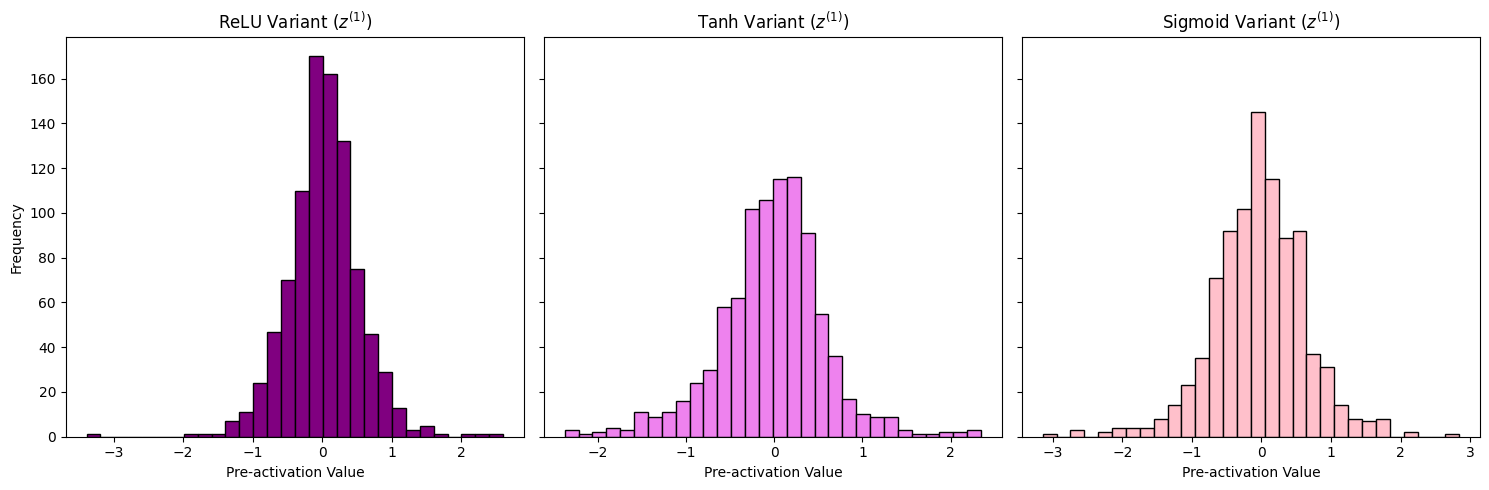

In [65]:
with torch.no_grad():
    z1_relu = model_relu.hidden(X_test_tensor).numpy()
    z1_tanh = model_tanh.hidden(X_test_tensor).numpy()
    z1_sigmoid = model_sigmoid.hidden(X_test_tensor).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axes[0].hist(z1_relu.flatten(), bins=30, color='purple', edgecolor='black')
axes[0].set_title('ReLU Variant ($z^{(1)}$)')
axes[0].set_xlabel('Pre-activation Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(z1_tanh.flatten(), bins=30, color='violet', edgecolor='black')
axes[1].set_title('Tanh Variant ($z^{(1)}$)')
axes[1].set_xlabel('Pre-activation Value')

axes[2].hist(z1_sigmoid.flatten(), bins=30, color='pink', edgecolor='black')
axes[2].set_title('Sigmoid Variant ($z^{(1)}$)')
axes[2].set_xlabel('Pre-activation Value')

plt.tight_layout()
plt.show()

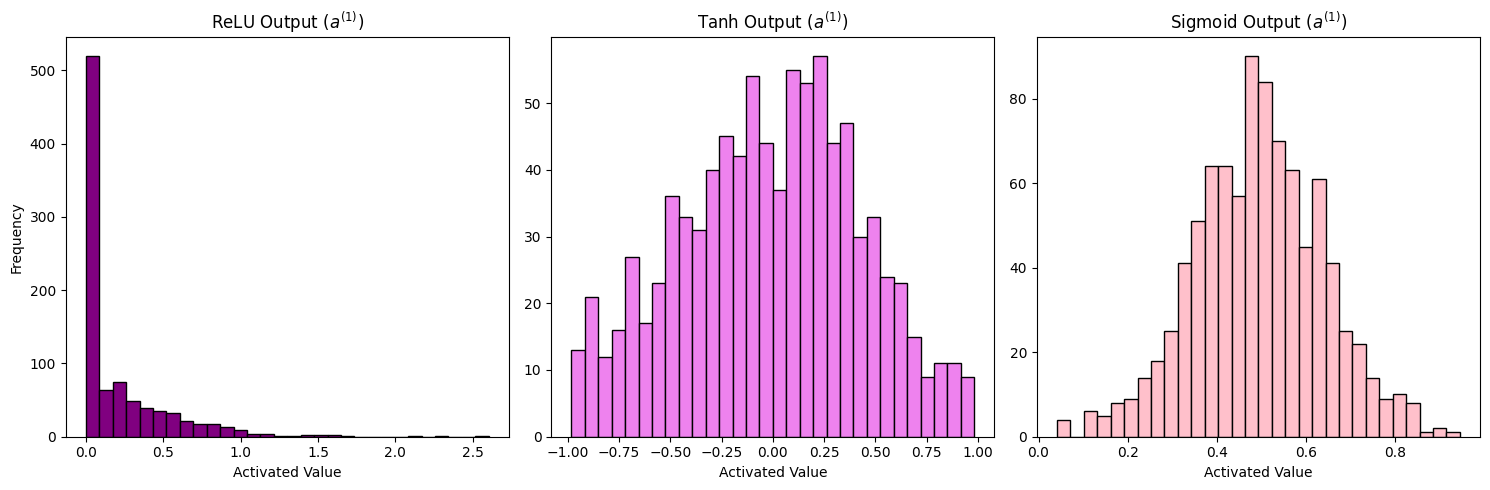

In [66]:
with torch.no_grad():
    a1_relu = model_relu.hidden_act(model_relu.hidden(X_test_tensor)).numpy()
    a1_tanh = model_tanh.hidden_act(model_tanh.hidden(X_test_tensor)).numpy()
    a1_sigmoid = model_sigmoid.hidden_act(model_sigmoid.hidden(X_test_tensor)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(a1_relu.flatten(), bins=30, color='purple', edgecolor='black')
axes[0].set_title('ReLU Output ($a^{(1)}$)')
axes[0].set_xlabel('Activated Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(a1_tanh.flatten(), bins=30, color='violet', edgecolor='black')
axes[1].set_title('Tanh Output ($a^{(1)}$)')
axes[1].set_xlabel('Activated Value')

axes[2].hist(a1_sigmoid.flatten(), bins=30, color='pink', edgecolor='black')
axes[2].set_title('Sigmoid Output ($a^{(1)}$)')
axes[2].set_xlabel('Activated Value')

plt.tight_layout()
plt.show()

**For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?**

- Sigmoid: Based on the histogram, only a very small fraction (roughly 5-10%) of values fall near the boundaries (0 or 1). Most activations are clustered around 0.5 because the pre-activation values $z^{(1)}$ were mostly between -2 and 2.
- Tanh: Similarly, a small fraction (roughly 10-15%) is close to the saturated regions of -1 and 1. The majority of the values stay in the "active" linear region (around 0).
- Significance: Saturation leads to the "Vanishing Gradient" problem, where the model stops learning because the derivative is nearly zero.

**Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?**

Looking at the tall bar at exactly 0.0, roughly 45-50% of the units are inactive. Since our pre-activation distribution was centered at 0, almost half of the input values were negative, and ReLU accurately "killed" them by turning them into 0.

**Based on these histograms, why might ReLU be the better default for hidden layers?**

Based on these histograms, ReLU is often preferred because:
- Sparsity: By deactivating ~50% of the neurons, ReLU creates a sparse representation, which is computationally efficient and helps prevent overfitting.
- No Saturation on the Positive Side: Unlike Sigmoid and Tanh, which flatten out as values increase, ReLU stays linear for all positive values. This completely avoids the vanishing gradient problem for half of the input space.
- Faster Convergence: Because the gradients do not vanish as quickly as they do in Sigmoid/Tanh, models using ReLU typically train much faster.